In [358]:
import ipywidgets as widgets
from IPython.display import display
import glob
import os

# Search paths for the POST WASH directory
post_wash_paths = [
    'Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '../Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '/Users/cjeong1021/Auto_OPDx_Flourescence/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '/Users/cjeong1021/auto_opdx/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '.'
]

image_dir = '.'
for path in post_wash_paths:
    if os.path.isdir(path):
        image_dir = path
        break

print(f"Listing images from: {os.path.abspath(image_dir)}")

# Get all image files in the directory
image_files = (
    glob.glob(os.path.join(image_dir, "*.jpg")) +
    glob.glob(os.path.join(image_dir, "*.jpeg")) +
    glob.glob(os.path.join(image_dir, "*.png"))
)
image_files.sort()

# CreateDropdown option tuples (basename, full_path)
dropdown_options = [(os.path.basename(f), f) for f in image_files]

# Create a dropdown widget
file_dropdown = widgets.Dropdown(
    options=dropdown_options,
    value=image_files[0] if image_files else None,
    description='Image File:',
    disabled=False,
    layout={'width': 'max-content'}
)

use_circle_mask_checkbox = widgets.Checkbox(
    value=False,
    description='Use Circular Mask',
    disabled=False
)

ordering_dropdown = widgets.Dropdown(
    options=['reversed', 'standard', 'p8'],
    value='reversed',
    description='OrderingStyle:',
    disabled=False
)

refinement_method_dropdown = widgets.Dropdown(
    options=['contour', 'projection', 'best'],
    value='contour',
    description='Refinement Method:',
    disabled=False
)

grid_rows = 8
grid_cols = 8

display(file_dropdown)
display(use_circle_mask_checkbox)
display(ordering_dropdown)
display(refinement_method_dropdown)


Listing images from: /Users/cjeong1021/Auto_OPDx_Flourescence/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL


Dropdown(description='Image File:', layout=Layout(width='max-content'), options=(('25 uM FL 200uM P5 A.jpg', '…

Checkbox(value=False, description='Use Circular Mask')

Dropdown(description='OrderingStyle:', options=('reversed', 'standard', 'p8'), value='reversed')

Dropdown(description='Refinement Method:', options=('contour', 'projection'), value='contour')

Processing file: /Users/cjeong1021/Auto_OPDx_Flourescence/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL/25 uM SCR080  200uM P8 B.jpg


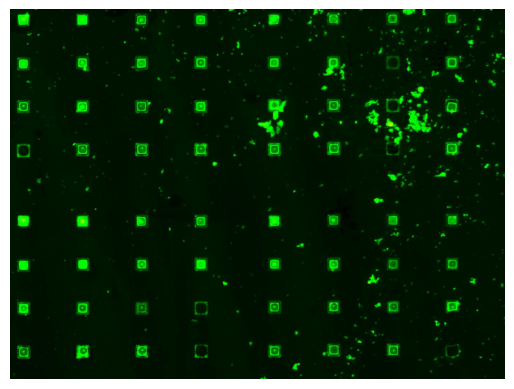

In [417]:
import cv2
import matplotlib.pyplot as plt

# Load image in BGR (OpenCV default)
filename = file_dropdown.value
print(f"Processing file: {filename}")
img_bgr = cv2.imread(filename)

# Convert BGR to RGB for Matplotlib
if img_bgr is None:
    print('Error: Could not load image. Please check the file path.')
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
    plt.imshow(img_rgb)
    plt.axis('off')  # Optional: hide axis ticks


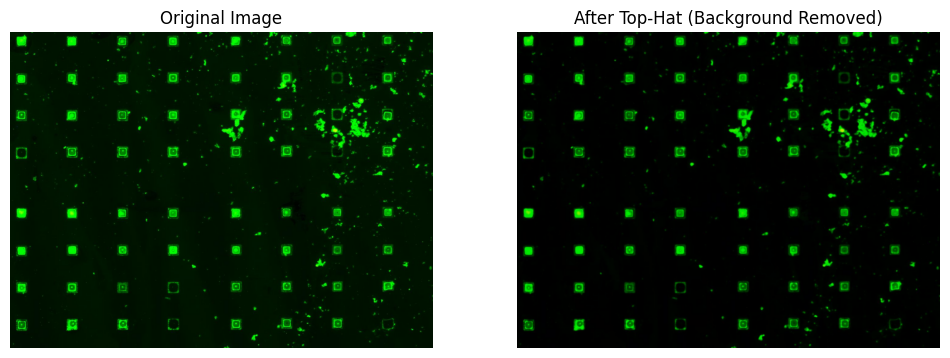

In [418]:
# Apply a median filter to the original image to reduce noise
img_median = cv2.medianBlur(img_rgb, 5)

# Define a structuring element for the Top-Hat transform
# IMPORTANT: The kernel size (here 51x51) MUST be larger than the squares you want to keep!
# Adjust the size accordingly if the squares are larger or smaller in your image.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (51, 51))

# Apply White Top-Hat transform
# This extracts bright objects on a dark background, effectively removing uneven illumination.
# (If your squares are dark on a bright background, use cv2.MORPH_BLACKHAT instead)
img_tophat = cv2.morphologyEx(img_median, cv2.MORPH_TOPHAT, kernel)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_tophat)
plt.title("After Top-Hat (Background Removed)")
plt.axis("off")
plt.show()


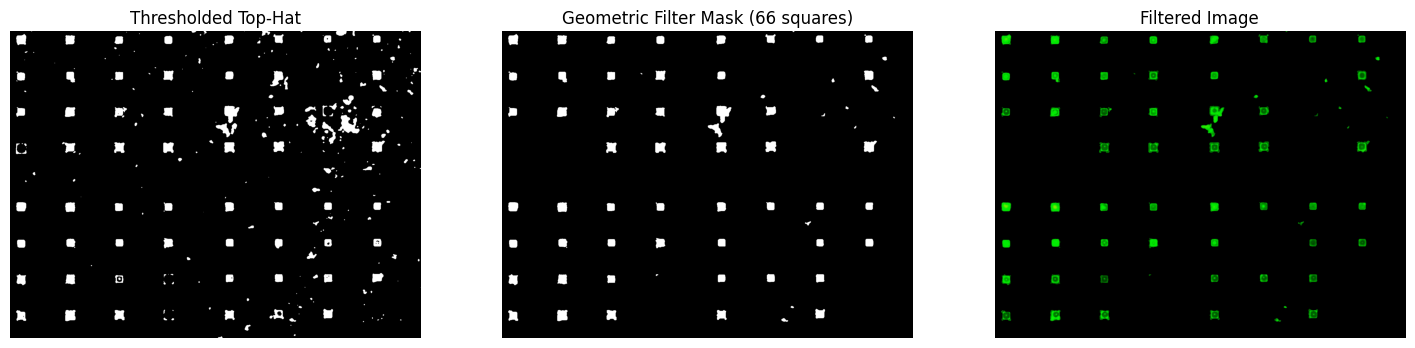

In [419]:
import numpy as np

# Convert to grayscale for thresholding and contour detection
gray_tophat = cv2.cvtColor(img_tophat, cv2.COLOR_RGB2GRAY)

# Threshold to isolate the bright features
_, binary_tophat = cv2.threshold(gray_tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours
contours, _ = cv2.findContours(binary_tophat, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours = []
for cnt in contours:
    # Approximate contour with a polygon
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
    
    # We are looking for square-like features, so we want polygons with 4 vertices
    if len(approx) == 4:
        # Check if the polygon is convex
        if cv2.isContourConvex(approx):
            # Compute bounding rectangle to check aspect ratio (width / height)
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            
            # A square will have an aspect ratio close to 1.0
            if 0.5 <= aspect_ratio <= 2.0:
                # Optional: filter by area to remove tiny noise or huge contours
                area = cv2.contourArea(cnt)
                if area > 10:  # Adjust this threshold based on actual square sizes
                    filtered_contours.append(cnt)

# Create an empty mask to draw the filtered square contours
mask = np.zeros_like(gray_tophat)
cv2.drawContours(mask, filtered_contours, -1, 255, thickness=cv2.FILLED)

# Filter out everything else using the mask on the tophat image
img_filtered = cv2.bitwise_and(img_tophat, img_tophat, mask=mask)

# Display the results
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(binary_tophat, cmap="gray")
plt.title("Thresholded Top-Hat")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Geometric Filter Mask ({len(filtered_contours)} squares)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_filtered)
plt.title("Filtered Image")
plt.axis("off")
plt.show()

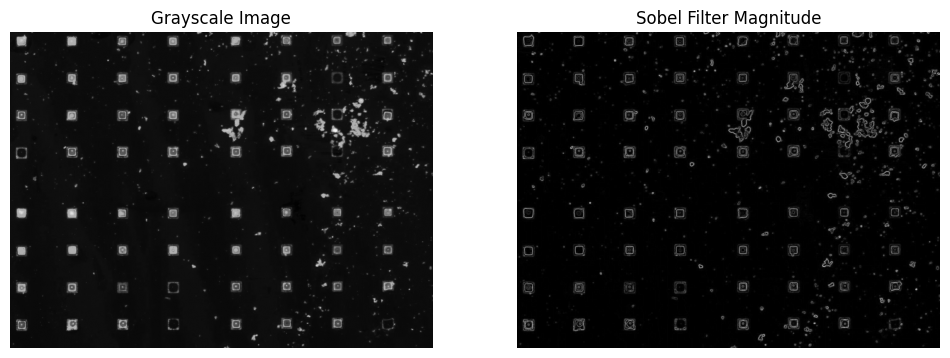

In [420]:
# Convert original image to grayscale for Sobel edge detection
gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply Sobel filter in X and Y directions
sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)

# Calculate the gradient magnitude
sobel_magnitude = cv2.magnitude(sobelx, sobely)

# Normalize the magnitude to 0-255 for display
sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Display the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Filter Magnitude")
plt.axis("off")
plt.show()


(np.float64(-0.5), np.float64(1391.5), np.float64(1039.5), np.float64(-0.5))

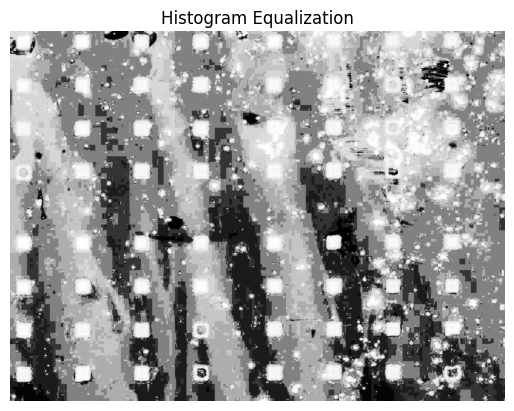

In [421]:
# Convert to HSV color space to perform histogram equalization on the Value channel
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Equalize the V channel
img_hsv[:, :] = cv2.equalizeHist(img_hsv[:, :])

# Display the equalized image
plt.imshow(img_hsv, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

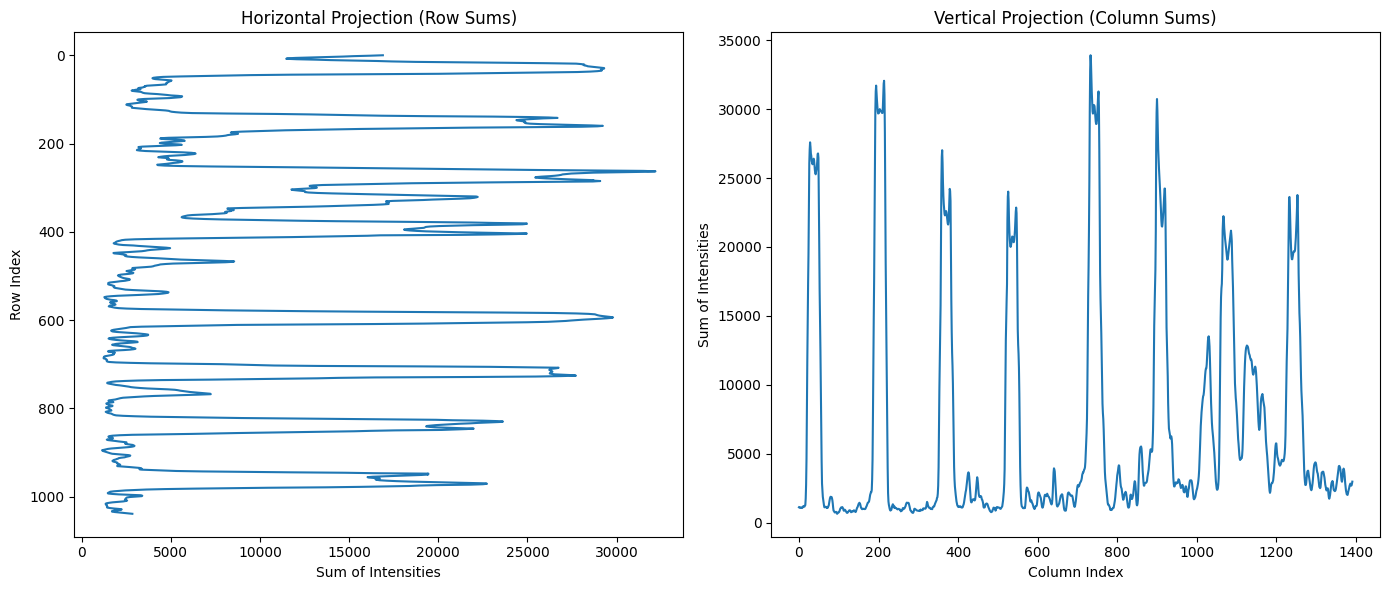

In [422]:
# Create 1D horizontal and vertical projection map
# Accumulating pixel intensities by column (vertical projection) and row (horizontal projection)
# We will use gray_tophat which is the grayscale top hat image from the previous cell

horizontal_projection = np.sum(gray_tophat, axis=1)
vertical_projection = np.sum(gray_tophat, axis=0)

plt.figure(figsize=(14, 6))

# Visualize horizontal projection
plt.subplot(1, 2, 1)
plt.plot(horizontal_projection, range(len(horizontal_projection)))
plt.gca().invert_yaxis() # Invert y-axis to match image orientation
plt.title('Horizontal Projection (Row Sums)')
plt.xlabel('Sum of Intensities')
plt.ylabel('Row Index')

# Visualize vertical projection
plt.subplot(1, 2, 2)
plt.plot(range(len(vertical_projection)), vertical_projection)
plt.title('Vertical Projection (Column Sums)')
plt.xlabel('Column Index')
plt.ylabel('Sum of Intensities')

plt.tight_layout()
plt.show()


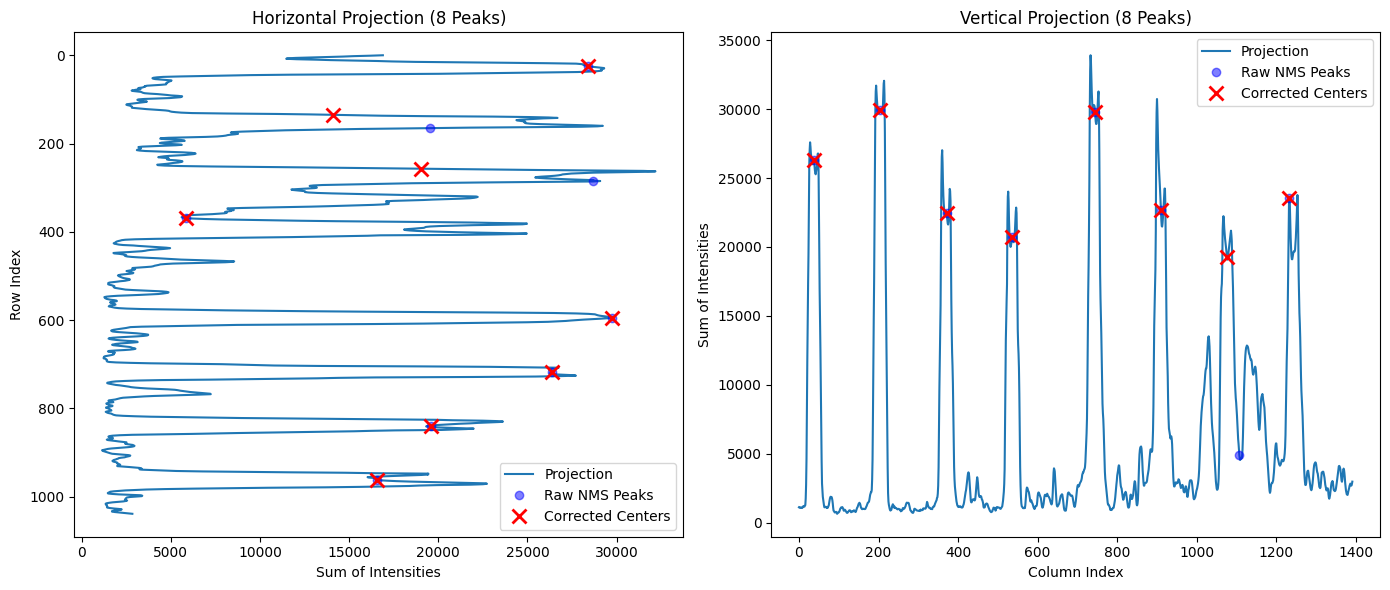

Horizontal grid row positions: [ 25 135 257 369 595 717 839 962]
Vertical grid column positions: [  38  204  371  536  744  910 1076 1232]


In [423]:
from scipy.signal import find_peaks

# Function to extract the top N peaks and calculate their centers from their boundaries
def get_top_n_peaks(projection, n, min_dist=30):
    # Find all peaks and their prominences
    peaks, properties = find_peaks(projection, prominence=np.max(projection)*0.015)
    prominences = properties["prominences"]
    
    # Greedily select top N peaks that are at least min_dist apart (Non-Maximum Suppression)
    sort_indices = np.argsort(prominences)[::-1]
    selected_peaks = []
    for idx in sort_indices:
        p = peaks[idx]
        too_close = False
        for sp in selected_peaks:
            if abs(p - sp) < min_dist:
                too_close = True
                break
        if not too_close:
            selected_peaks.append(p)
            if len(selected_peaks) == n:
                break
                
    # Sort peaks geometrically
    selected_peaks = np.sort(selected_peaks)
    
    # Find the lower boundaries for each peak and compute the midpoint center
    centers = []
    threshold_ratio = 0.15
    for idx, p in enumerate(selected_peaks):
        val = projection[p]
        thresh = val * threshold_ratio
        
        min_left = 0
        if idx > 0:
            min_left = (selected_peaks[idx-1] + p) // 2
            
        max_right = len(projection) - 1
        if idx < len(selected_peaks) - 1:
            max_right = (p + selected_peaks[idx+1]) // 2
            
        left = p
        while left > min_left and projection[left] > thresh:
            left -= 1
            
        right = p
        while right < max_right and projection[right] > thresh:
            right += 1
            
        center = int((left + right) / 2)
        centers.append(center)
        
    return np.array(centers)

def fit_robust_loss_grid(nms_centers):
    if len(nms_centers) < 2:
        return nms_centers
    dists = np.diff(nms_centers)
    s_med = np.median([dists[i] for i in range(len(dists)) if i != 3]) if len(dists) > 3 else 120.0
    g_est = dists[3] if len(dists) > 3 else 200.0
    
    s_range = np.arange(max(10.0, s_med - 4), s_med + 5, 0.5)
    g_range = np.arange(max(10.0, g_est - 10), g_est + 11, 1)
    offset_range = np.arange(nms_centers[0] - 15, nms_centers[0] + 16, 1)
    
    best_cost = float('inf')
    best_grid = None
    
    for s in s_range:
        for g in g_range:
            for offset in offset_range:
                grid = []
                for i in range(8):
                    if i < 4:
                        pos = offset + i * s
                    else:
                        pos = offset + 3 * s + g + (i - 4) * s
                    grid.append(pos)
                grid = np.array(grid)
                
                cost = 0
                for gp in grid:
                    d = np.min(np.abs(nms_centers - gp))
                    cost += min(15.0, d)
                    
                if cost < best_cost:
                    best_cost = cost
                    best_grid = grid
                    
    return np.round(best_grid).astype(int)

def get_hybrid_centers_robust(projection, n_lines=8, is_horizontal=True, max_deviation=None):
    nms_centers = get_top_n_peaks(projection, n_lines, min_dist=30)
    if n_lines != 8 or len(nms_centers) != n_lines:
        return nms_centers
    grid_centers = fit_robust_loss_grid(nms_centers)
    
    if max_deviation is None:
        max_deviation = 18 if is_horizontal else 22
        
    corrected_centers = []
    for i in range(n_lines):
        gc = grid_centers[i]
        best_nms = None
        min_d = float('inf')
        for nc in nms_centers:
            d = abs(nc - gc)
            if d < min_d:
                min_d = d
                best_nms = nc
        if min_d > max_deviation:
            corrected_centers.append(int(gc))
        else:
            corrected_centers.append(int(best_nms))
    return np.sort(np.array(corrected_centers))

# Find 8 local peaks (robust hybrid grid fitting) for both axes
horizontal_peaks = get_hybrid_centers_robust(horizontal_projection, grid_rows, is_horizontal=True)
vertical_peaks = get_hybrid_centers_robust(vertical_projection, grid_cols, is_horizontal=False)

# Get raw NMS peaks for comparison visualization
horizontal_nms = get_top_n_peaks(horizontal_projection, grid_rows)
vertical_nms = get_top_n_peaks(vertical_projection, grid_cols)

# Visualize the peaks on the projections
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(horizontal_projection, range(len(horizontal_projection)), label="Projection")
plt.plot(horizontal_projection[horizontal_nms], horizontal_nms, "bo", alpha=0.5, label="Raw NMS Peaks")
plt.plot(horizontal_projection[horizontal_peaks], horizontal_peaks, "rx", markersize=10, markeredgewidth=2, label="Corrected Centers")
plt.gca().invert_yaxis()
plt.title(f'Horizontal Projection ({len(horizontal_peaks)} Peaks)')
plt.xlabel('Sum of Intensities')
plt.ylabel('Row Index')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(vertical_projection)), vertical_projection, label="Projection")
plt.plot(vertical_nms, vertical_projection[vertical_nms], "bo", alpha=0.5, label="Raw NMS Peaks")
plt.plot(vertical_peaks, vertical_projection[vertical_peaks], "rx", markersize=10, markeredgewidth=2, label="Corrected Centers")
plt.title(f'Vertical Projection ({len(vertical_peaks)} Peaks)')
plt.xlabel('Column Index')
plt.ylabel('Sum of Intensities')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Horizontal grid row positions: {horizontal_peaks}")
print(f"Vertical grid column positions: {vertical_peaks}")


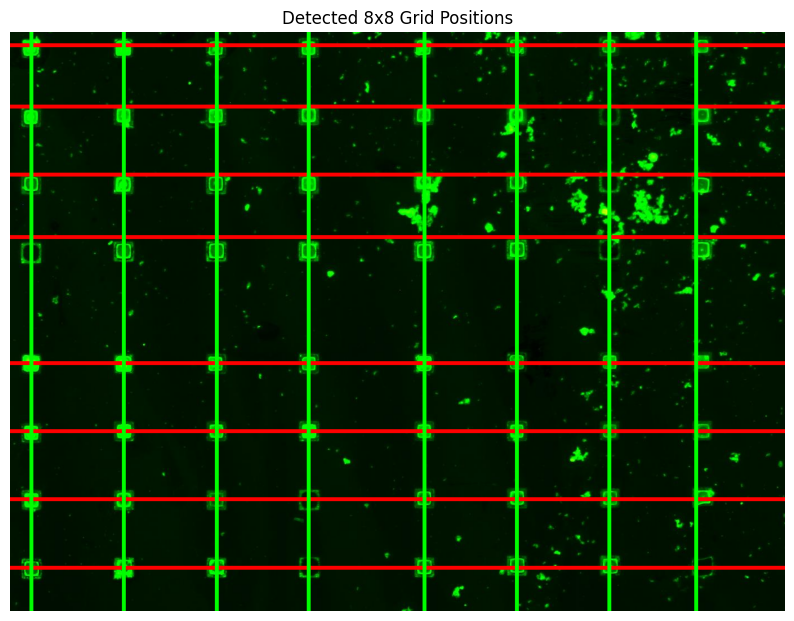

In [424]:
# Create a copy of the original RGB image to draw the grid lines
img_grid = img_rgb.copy()

# Draw horizontal grid lines (rows) based on detected peaks
for row_idx in horizontal_peaks:
    # OpenCV uses (x, y) coordinates, so row index is y
    cv2.line(img_grid, (0, row_idx), (img_grid.shape[1], row_idx), (255, 0, 0), thickness=5) # Red lines for rows

# Draw vertical grid lines (columns) based on detected peaks
for col_idx in vertical_peaks:
    # column index is x
    cv2.line(img_grid, (col_idx, 0), (col_idx, img_grid.shape[0]), (0, 255, 0), thickness=5) # Green lines for columns

# Display the original image with the overlayed grid
plt.figure(figsize=(10, 10))
plt.imshow(img_grid)
plt.title("Detected 8x8 Grid Positions")
plt.axis("off")
plt.show()


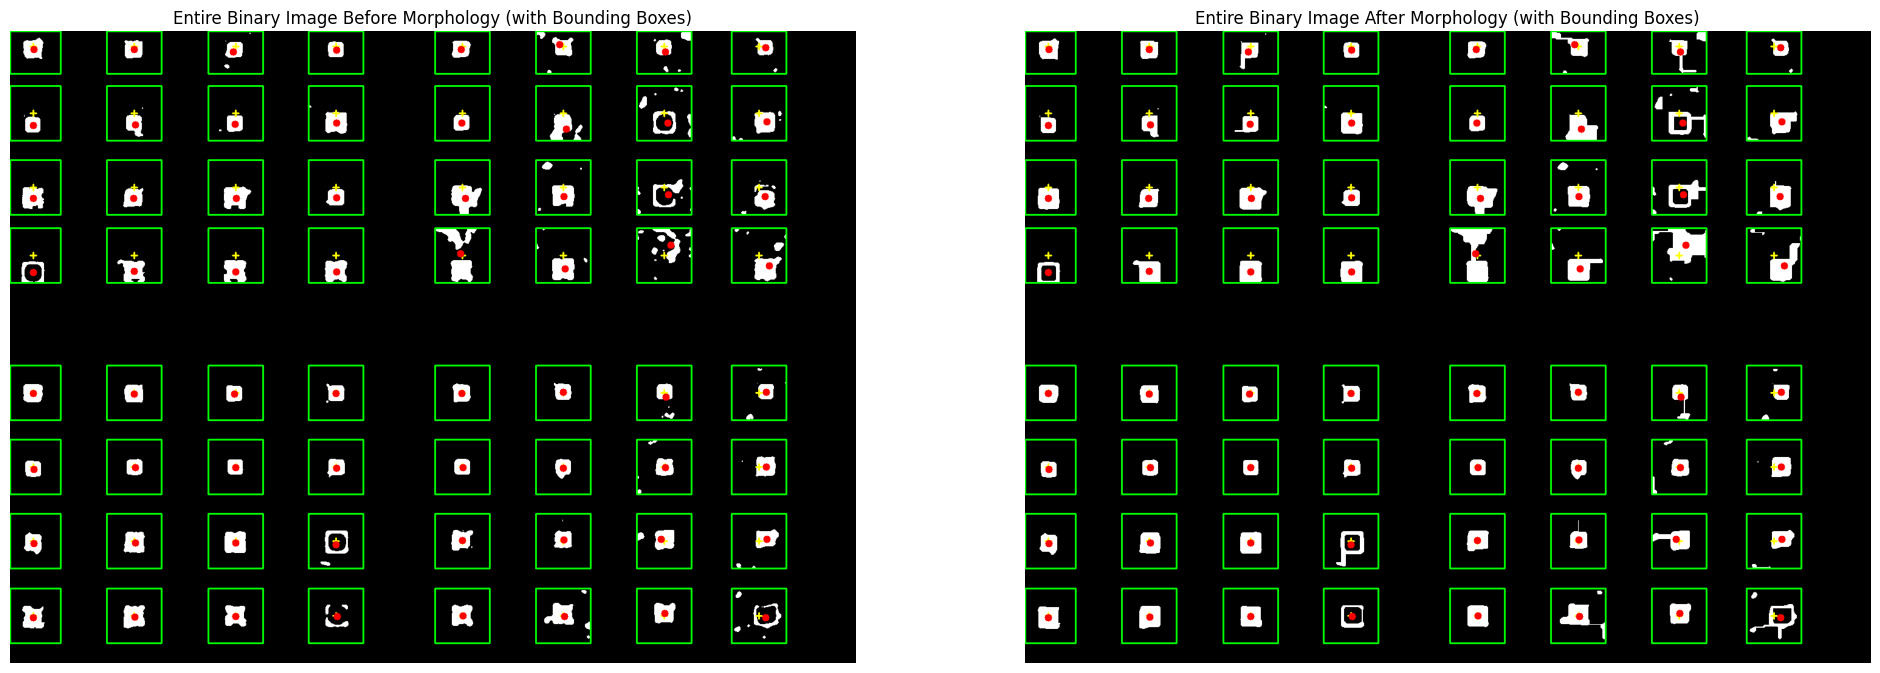

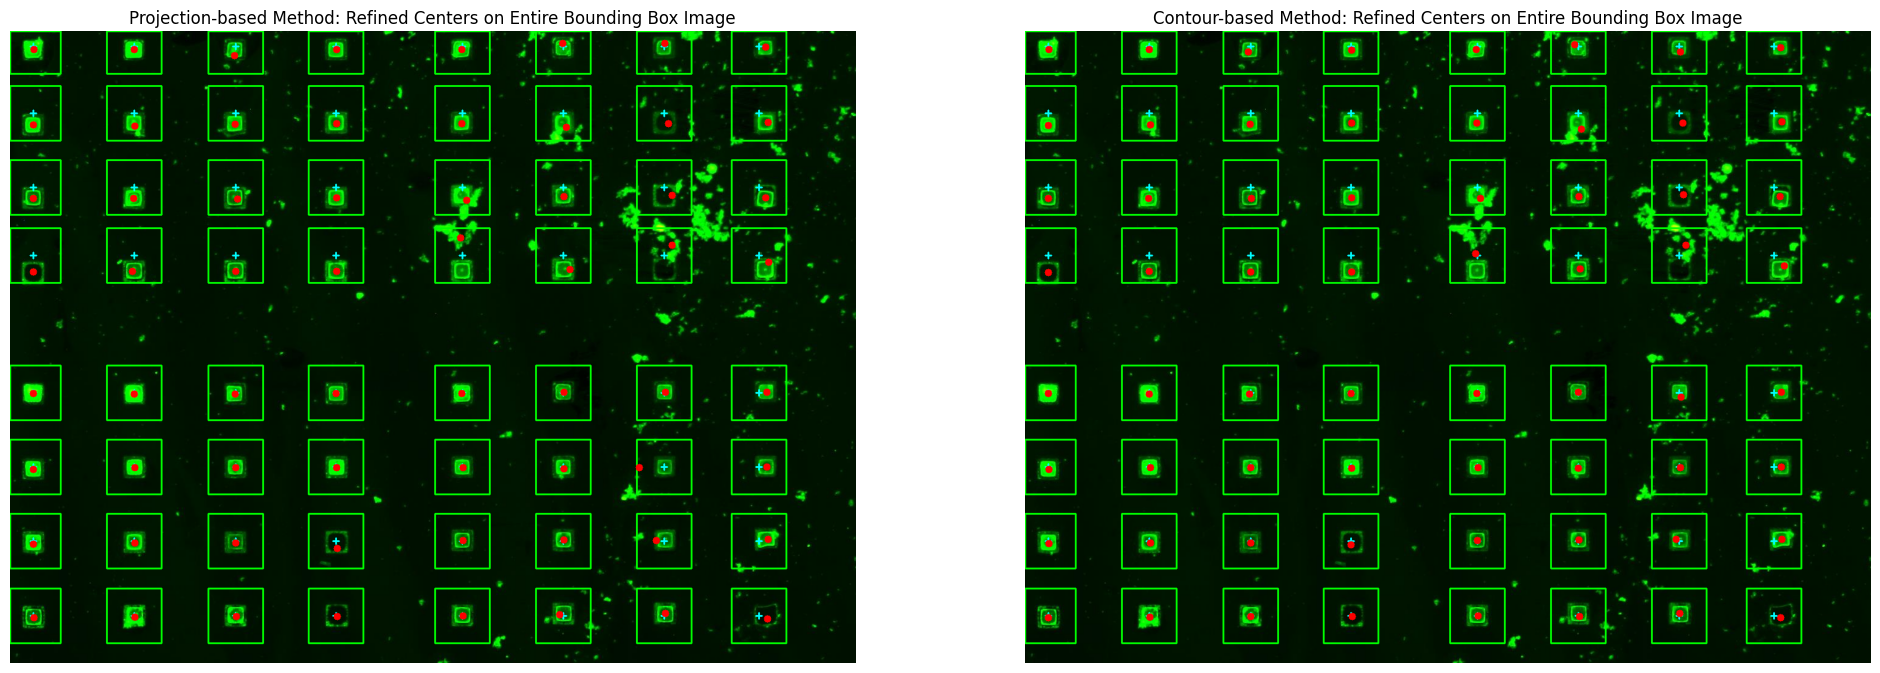

Total features detected: 64 (Grid: 8x8)
Top-left feature center (x, y): (39, 30)


In [ ]:
# Calculate refined centers using BOTH methods with local morphology
feature_centers_proj = []
feature_centers_cont = []
global_centers = []

# Search window size (80x80)
window_size = 80
half_w = window_size // 2

# Create blank global canvases for local binarization visualization
binary_before = np.zeros_like(gray_tophat)
binary_after = np.zeros_like(gray_tophat)

for r_idx, row_idx in enumerate(horizontal_peaks):
    row_proj = []
    row_cont = []
    global_row = []
    for c_idx, col_idx in enumerate(vertical_peaks):
        cx, cy = col_idx, row_idx
        global_row.append((cx, cy))
        
        # Local search bounds
        x_min = max(0, cx - half_w)
        x_max = min(gray_tophat.shape[1], cx + half_w)
        y_min = max(0, cy - half_w)
        y_max = min(gray_tophat.shape[0], cy + half_w)
        
        local_region = gray_tophat[y_min:y_max, x_min:x_max]
        
        # Default fallback centers
        p_cx, p_cy = cx, cy
        c_cx, c_cy = cx, cy
        
        if local_region.size > 0 and np.max(local_region) >= 10 and np.max(local_region) - np.min(local_region) >= 5:
            local_region_u8 = local_region.astype(np.uint8)
            ksize = max(5, int(window_size // 2) | 1)
            padded = cv2.copyMakeBorder(local_region_u8, ksize, ksize, ksize, ksize, cv2.BORDER_CONSTANT, value=0)
            _, thresh_padded = cv2.threshold(padded, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
            closed_padded = cv2.morphologyEx(thresh_padded, cv2.MORPH_CLOSE, kernel)
            
            thresh_cropped = thresh_padded[ksize:-ksize, ksize:-ksize]
            closed_cropped = closed_padded[ksize:-ksize, ksize:-ksize]
            
            # Paste local binarized spots into global canvases
            binary_before[y_min:y_max, x_min:x_max] = thresh_cropped
            binary_after[y_min:y_max, x_min:x_max] = closed_cropped
            
            # 1. Projection-based method
            proj_y = np.sum(closed_cropped, axis=1)
            proj_x = np.sum(closed_cropped, axis=0)
            
            def get_peak_center(proj, fallback_val):
                p = np.argmax(proj)
                val = proj[p]
                if val == 0:
                    return fallback_val
                thresh_val = val * 0.15
                left = p
                while left > 0 and proj[left] > thresh_val:
                    left -= 1
                right = p
                while right < len(proj) - 1 and proj[right] > thresh_val:
                    right += 1
                return (left + right) / 2.0
                
            cy_local_proj = get_peak_center(proj_y, cy - y_min)
            cx_local_proj = get_peak_center(proj_x, cx - x_min)
            p_cx = x_min + int(round(cx_local_proj))
            p_cy = y_min + int(round(cy_local_proj))
            
            # 2. Contour-based method
            contours, _ = cv2.findContours(closed_cropped, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            best_contour = None
            min_dist_to_center = float('inf')
            center_local_x = (x_max - x_min) / 2.0
            center_local_y = (y_max - y_min) / 2.0
            
            for cnt in contours:
                area = cv2.contourArea(cnt)
                if area < 20:
                    continue
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    bcx = M["m10"] / M["m00"]
                    bcy = M["m01"] / M["m00"]
                else:
                    bx, by, bw, bh = cv2.boundingRect(cnt)
                    bcx = bx + bw / 2.0
                    bcy = by + bh / 2.0
                dist = (bcx - center_local_x)**2 + (bcy - center_local_y)**2
                if dist < min_dist_to_center:
                    min_dist_to_center = dist
                    best_contour = cnt
                    
            if best_contour is not None:
                M = cv2.moments(best_contour)
                if M["m00"] != 0:
                    cx_local_cont = M["m10"] / M["m00"]
                    cy_local_cont = M["m01"] / M["m00"]
                else:
                    bx, by, bw, bh = cv2.boundingRect(best_contour)
                    cx_local_cont = bx + bw / 2.0
                    cy_local_cont = by + bh / 2.0
                c_cx = x_min + int(round(cx_local_cont))
                c_cy = y_min + int(round(cy_local_cont))
            else:
                c_cx, c_cy = p_cx, p_cy
                
        row_proj.append((p_cx, p_cy))
        row_cont.append((c_cx, c_cy))
        
    feature_centers_proj.append(row_proj)
    feature_centers_cont.append(row_cont)
    global_centers.append(global_row)

# Set active centers depending on the toggle
refinement_method = refinement_method_dropdown.value
if refinement_method == 'contour':
    feature_centers = feature_centers_cont
elif refinement_method == 'projection':
    feature_centers = feature_centers_proj
else:
    # 'best' confidence-based selection per spot
    feature_centers = []
    for r_idx in range(len(horizontal_peaks)):
        row = []
        for c_idx in range(len(vertical_peaks)):
            cx, cy = vertical_peaks[c_idx], horizontal_peaks[r_idx]
            ccx, ccy = feature_centers_cont[r_idx][c_idx]
            pcx, pcy = feature_centers_proj[r_idx][c_idx]
            if (ccx, ccy) == (pcx, pcy):
                row.append((ccx, ccy))
            else:
                def get_mean_intensity(img, cx, cy, box_w=20):
                    hw = box_w // 2
                    x_min = max(0, cx - hw)
                    x_max = min(img.shape[1], cx + hw)
                    y_min = max(0, cy - hw)
                    y_max = min(img.shape[0], cy + hw)
                    region = img[y_min:y_max, x_min:x_max]
                    if region.size == 0:
                        return 0.0
                    return float(np.mean(region))
                def compute_confidence(mean_val, dist):
                    penalty = 0.0
                    if dist > 15:
                        penalty = (dist - 15) * 2.0
                    if dist > 30:
                        penalty += 100.0
                    return mean_val - penalty
                mean_c = get_mean_intensity(gray_tophat, ccx, ccy, 20)
                dist_c = np.sqrt((ccx - cx)**2 + (ccy - cy)**2)
                conf_c = compute_confidence(mean_c, dist_c)
                mean_p = get_mean_intensity(gray_tophat, pcx, pcy, 20)
                dist_p = np.sqrt((pcx - cx)**2 + (pcy - cy)**2)
                conf_p = compute_confidence(mean_p, dist_p)
                if conf_c >= conf_p:
                    row.append((ccx, ccy))
                else:
                    row.append((pcx, pcy))
        feature_centers.append(row)

img_before_show = cv2.cvtColor(binary_before, cv2.COLOR_GRAY2RGB)
img_after_show = cv2.cvtColor(binary_after, cv2.COLOR_GRAY2RGB)
img_proj_overlay = img_rgb.copy()
img_cont_overlay = img_rgb.copy()

for r_idx, row_idx in enumerate(horizontal_peaks):
    for c_idx, col_idx in enumerate(vertical_peaks):
        cx, cy = col_idx, row_idx
        p_cx, p_cy = feature_centers_proj[r_idx][c_idx]
        c_cx, c_cy = feature_centers_cont[r_idx][c_idx]
        
        x_min = max(0, cx - half_w)
        x_max = min(gray_tophat.shape[1], cx + half_w)
        y_min = max(0, cy - half_w)
        y_max = min(gray_tophat.shape[0], cy + half_w)
        
        # Draw on BEFORE/AFTER binarized images
        cv2.rectangle(img_before_show, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_before_show, (cx, cy), color=(255, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_before_show, (c_cx, c_cy), radius=6, color=(255, 0, 0), thickness=-1)
        
        cv2.rectangle(img_after_show, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_after_show, (cx, cy), color=(255, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_after_show, (c_cx, c_cy), radius=6, color=(255, 0, 0), thickness=-1)
        
        # Draw on projection overlay image
        cv2.rectangle(img_proj_overlay, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_proj_overlay, (cx, cy), color=(0, 255, 255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_proj_overlay, (p_cx, p_cy), radius=6, color=(255, 0, 0), thickness=-1)
        
        # Draw on contour overlay image
        cv2.rectangle(img_cont_overlay, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_cont_overlay, (cx, cy), color=(0, 255, 255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_cont_overlay, (c_cx, c_cy), radius=6, color=(255, 0, 0), thickness=-1)

# Plot the entire binarized image before and after morphology side-by-side
plt.figure(figsize=(24, 12))
plt.subplot(1, 2, 1)
plt.imshow(img_before_show)
plt.title("Entire Binary Image Before Morphology (with Bounding Boxes)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_after_show)
plt.title("Entire Binary Image After Morphology (with Bounding Boxes)")
plt.axis('off')
plt.show()

# Plot BOTH overlays side-by-side showing the entire original image
plt.figure(figsize=(24, 12))
plt.subplot(1, 2, 1)
plt.imshow(img_proj_overlay)
plt.title("Projection-based Method: Refined Centers on Entire Bounding Box Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_cont_overlay)
plt.title("Contour-based Method: Refined Centers on Entire Bounding Box Image")
plt.axis('off')
plt.show()

print(f"Total features detected: {len(feature_centers) * len(feature_centers[0])} (Grid: {len(feature_centers)}x{len(feature_centers[0])})")
print(f"Top-left feature center (x, y): {feature_centers[0][0]}")


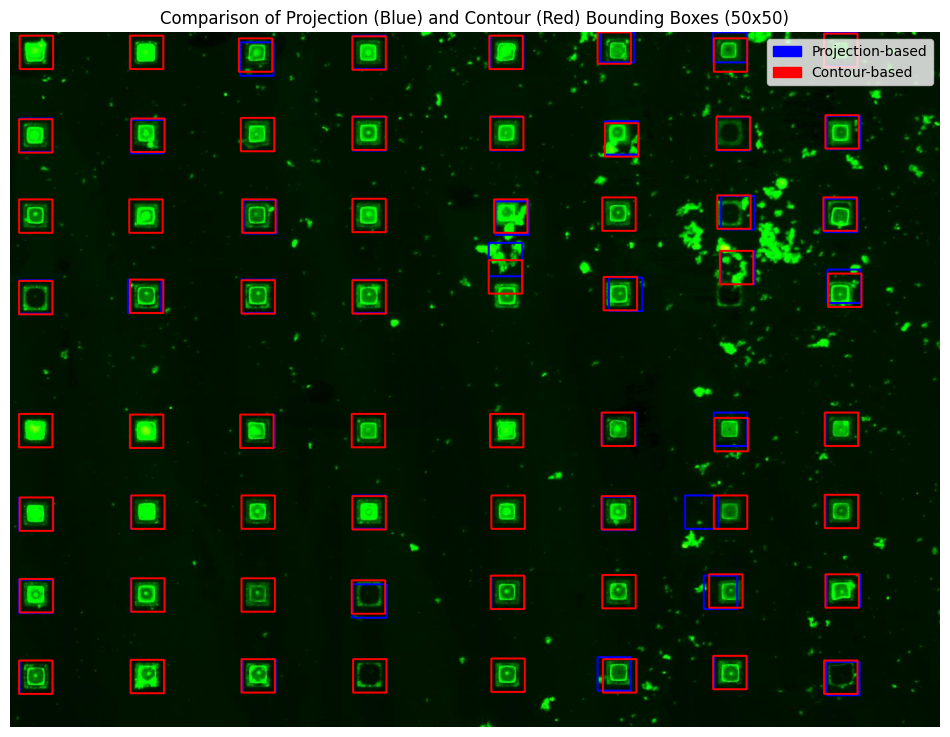

In [450]:
# Define a fixed box size based on the square features (e.g., 15x15 pixels)
box_width = 50
box_height = 50

img_boxes = img_rgb.copy()
hw = box_width // 2
hh = box_height // 2

# Draw projection-based bounding boxes in Blue
for row in feature_centers_proj:
    for cx, cy in row:
        top_left = (max(0, cx - hw), max(0, cy - hh))
        bottom_right = (min(img_boxes.shape[1], cx + hw), min(img_boxes.shape[0], cy + hh))
        cv2.rectangle(img_boxes, top_left, bottom_right, (0, 0, 255), thickness=2)

# Draw contour-based bounding boxes in Red
for row in feature_centers_cont:
    for cx, cy in row:
        top_left = (max(0, cx - hw), max(0, cy - hh))
        bottom_right = (min(img_boxes.shape[1], cx + hw), min(img_boxes.shape[0], cy + hh))
        cv2.rectangle(img_boxes, top_left, bottom_right, (255, 0, 0), thickness=2)
        
# Display the result
plt.figure(figsize=(12, 12))
plt.imshow(img_boxes)
plt.title(f"Comparison of Projection (Blue) and Contour (Red) Bounding Boxes ({box_width}x{box_height})")

# Add a legend
import matplotlib.patches as mpatches
proj_patch = mpatches.Patch(color='blue', label='Projection-based')
cont_patch = mpatches.Patch(color='red', label='Contour-based')
plt.legend(handles=[proj_patch, cont_patch], loc='upper right')

plt.axis("off")
plt.show()


## Confidence Scoring Method Explanation

To automatically choose the best center for each spot, we run both the **Contour-based** (moments centroid) and the **Projection-based** (profile midpoint) methods, and select the coordinate with the higher **Confidence Score**.

### The Confidence Score Formula

For any candidate refined center coordinate $(x_c, y_c)$ and initial grid guess $(c_x, c_y)$:

$$ \text{Confidence} = \text{Signal Strength} - \text{Penalty} $$

1. **Signal Strength (Local Mean Intensity)**:
   We compute the mean intensity of the background-subtracted `gray_tophat` image in a small $20 \times 20$ pixel window centered at $(x_c, y_c)$. Because the spots are bright and the background is dark, the mean intensity is maximized when the window is perfectly centered on the spot.
   
2. **Distance Penalty**:
   We penalize the candidate center if it drifts too far from the initial grid guess $(c_x, c_y)$ to prevent it from latching onto neighboring spots or noise artifacts:
   - If distance $D \le 15$ pixels: $\text{Penalty} = 0$.
   - If $15 < D \le 30$ pixels: $\text{Penalty} = (D - 15) \times 2.0$.
   - If $D > 30$ pixels: $\text{Penalty} = (D - 15) \times 2.0 + 100.0$ (heavy penalty to suppress outliers).


In [ ]:
# Visualizing and explaining confidence scoring
# Let's inspect some spots (e.g. the first 5 spots in row 0) and compare their contour vs projection centers and confidence scores
import matplotlib.patches as patches

def get_mean_intensity(img, cx, cy, box_w=20):
    hw = box_w // 2
    x_min = max(0, cx - hw)
    x_max = min(img.shape[1], cx + hw)
    y_min = max(0, cy - hw)
    y_max = min(img.shape[0], cy + hw)
    region = img[y_min:y_max, x_min:x_max]
    if region.size == 0:
        return 0.0
    return float(np.mean(region))

def compute_confidence(mean_val, dist):
    penalty = 0.0
    if dist > 15:
        penalty = (dist - 15) * 2.0
    if dist > 30:
        penalty += 100.0
    return mean_val - penalty

fig, axes = plt.subplots(8, 8, figsize=(40, 40))
for r_idx in range(8):
    for c_idx in range(8):
        cx, cy = vertical_peaks[c_idx], horizontal_peaks[r_idx]
        ccx, ccy = feature_centers_cont[r_idx][c_idx]
        pcx, pcy = feature_centers_proj[r_idx][c_idx]
        
        # Crop local 80x80 area from gray_tophat
        hw_local = 40
        x_min = max(0, cx - hw_local)
        x_max = min(gray_tophat.shape[1], cx + hw_local)
        y_min = max(0, cy - hw_local)
        y_max = min(gray_tophat.shape[0], cy + hw_local)
        local_crop = gray_tophat[y_min:y_max, x_min:x_max]
        
        # Calculate values
        dist_c = np.sqrt((ccx - cx)**2 + (ccy - cy)**2)
        mean_c = get_mean_intensity(gray_tophat, ccx, ccy, 20)
        conf_c = compute_confidence(mean_c, dist_c)
        
        dist_p = np.sqrt((pcx - cx)**2 + (pcy - cy)**2)
        mean_p = get_mean_intensity(gray_tophat, pcx, pcy, 20)
        conf_p = compute_confidence(mean_p, dist_p)
        
        ax = axes[r_idx, c_idx]
        ax.imshow(local_crop, cmap='gray')
        
        # Local offsets
        lc_c = (ccx - x_min, ccy - y_min)
        lc_p = (pcx - x_min, pcy - y_min)
        lc_init = (cx - x_min, cy - y_min)
        
        # Plot centers
        ax.plot(lc_init[0], lc_init[1], 'yx', markersize=14, markeredgewidth=2.0, label='Grid Init' if (r_idx==0 and c_idx==0) else "")
        ax.plot(lc_c[0], lc_c[1], 'ro', markersize=11, label='Contour' if (r_idx==0 and c_idx==0) else "")
        ax.plot(lc_p[0], lc_p[1], 'bs', markersize=9, label='Projection' if (r_idx==0 and c_idx==0) else "")
        
        # Highlight chosen center with a green circle border
        if conf_c >= conf_p:
            chosen_x, chosen_y = lc_c
            chosen_label = "Contour"
        else:
            chosen_x, chosen_y = lc_p
            chosen_label = "Projection"
            
        circ = patches.Circle((chosen_x, chosen_y), radius=12, linewidth=2.5, edgecolor='g', facecolor='none', label='Chosen' if (r_idx==0 and c_idx==0) else "")
        ax.add_patch(circ)
        
        ax.set_title(f"R{r_idx}C{c_idx}\nC:{conf_c:.1f} P:{conf_p:.1f}\n{chosen_label}", fontsize=14)
        ax.axis('off')

plt.suptitle("Local Search Regions (8x8 Grid) with Refined Centers & Confidence Scores (Otsu-Gray)", fontsize=28, y=1.01)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.0, -0.2), ncol=4, fontsize=16)
plt.tight_layout()
plt.show()


In [451]:
import pandas as pd
import numpy as np
import os

# Read UI widget parameters
use_circle_mask = use_circle_mask_checkbox.value
ordering = ordering_dropdown.value

# Reorder the features into 4 quadrants (groups of 16 data points) 
# to match exactly the ordering from the spreadsheet / GUI settings
quadrant_ranges = [
    ((0, 4), (0, 4)), # Quadrant 1
    ((0, 4), (4, 8)), # Quadrant 2
    ((4, 8), (0, 4)), # Quadrant 3
    ((4, 8), (4, 8))  # Quadrant 4
]

if ordering == 'reversed':
    rev_r, rev_c = True, True
elif ordering == 'standard':
    rev_r, rev_c = False, False
elif ordering == 'p8':
    rev_r, rev_c = False, True
else:
    rev_r, rev_c = True, True

ordered_centers = []
for col_range, row_range in quadrant_ranges:
    for r in sorted(range(row_range[0], row_range[1]), reverse=rev_r):
        for c in sorted(range(col_range[0], col_range[1]), reverse=rev_c):
            ordered_centers.append(feature_centers[r][c])

# Extract statistics for each feature
results = []
box_size = box_width  # using box_width as box_size

# Construct circular mask if enabled
if use_circle_mask:
    w = box_size
    y_grid, x_grid = np.ogrid[:w, :w]
    if w == 51:
        cx_mask, cy_mask = 25.5, 25.5
        radius = 30.0
    else:
        cx_mask = (w - 1) / 2.0
        cy_mask = (w - 1) / 2.0
        radius = 30.0 * (w / 51.0)
    mask = (x_grid - cx_mask)**2 + (y_grid - cy_mask)**2 <= radius**2
    area_val = int(np.sum(mask))
else:
    area_val = box_size * box_size

for i, (cx, cy) in enumerate(ordered_centers):
    # Compute bounding box centered at cx, cy
    x_min = max(0, cx - box_size // 2)
    x_max = min(img_rgb.shape[1], cx - box_size // 2 + box_size)
    y_min = max(0, cy - box_size // 2)
    y_max = min(img_rgb.shape[0], cy - box_size // 2 + box_size)
    
    region_rgb = img_rgb[y_min:y_max, x_min:x_max].astype(float)
    if region_rgb.size == 0:
        mean_val, std_val, min_val, max_val = 0.0, 0.0, 0.0, 0.0
        actual_area = 0
    else:
        region = np.mean(region_rgb, axis=2).astype(np.uint8)
        if use_circle_mask:
            if region.shape == (box_size, box_size):
                pixels = region[mask]
                actual_area = area_val
            else:
                # Handle borders symmetrically
                mask_y_min = max(0, - (cy - box_size // 2))
                mask_y_max = mask_y_min + region.shape[0]
                mask_x_min = max(0, - (cx - box_size // 2))
                mask_x_max = mask_x_min + region.shape[1]
                cropped_mask = mask[mask_y_min:mask_y_max, mask_x_min:mask_x_max]
                pixels = region[cropped_mask]
                actual_area = int(np.sum(cropped_mask))
        else:
            pixels = region
            actual_area = region.size
            
        if pixels.size == 0:
            mean_val, std_val, min_val, max_val = 0.0, 0.0, 0.0, 0.0
        else:
            mean_val = np.mean(pixels)
            std_val = np.std(pixels)
            min_val = np.min(pixels)
            max_val = np.max(pixels)
            
    results.append({
        'component_id': i + 1,
        'centroid_x': cx,
        'centroid_y': cy,
        'area': actual_area,
        'mean_brightness': mean_val,
        'std_deviation': std_val,
        'min_value': min_val,
        'max_value': max_val
    })

# Create DataFrame
df_fluorescence = pd.DataFrame(results)

# Save to CSV matching the GUI output format
base_name = os.path.splitext(os.path.basename(file_dropdown.value))[0]
csv_filename = f"fluorescence_data_{base_name}.csv"
with open(csv_filename, 'w', encoding='utf-8') as f:
    f.write(f"{base_name}\n")
    f.write("Num,Area,Mean,StdDev,Min,Max\n")
    for i, row in df_fluorescence.iterrows():
        f.write(f"{int(row['component_id'])},{int(row['area'])},{row['mean_brightness']:.6f},{row['std_deviation']:.6f},{int(row['min_value'])},{int(row['max_value'])}\n")
        if (i + 1) % 16 == 0 and (i + 1) != len(df_fluorescence):
            f.write("\n")

print(f"Data saved to: {csv_filename}")
display(df_fluorescence)


Data saved to: fluorescence_data_25 uM SCR080  200uM P8 B.csv


,component_id,centroid_x,centroid_y,area,mean_brightness,std_deviation,min_value,max_value
0,1,537,396,2500,33.1896,26.752302,5,109
1,2,371,396,2500,31.2656,26.301389,5,123
2,3,204,395,2500,31.0888,25.635134,5,112
3,4,38,397,2500,20.0148,18.089339,5,124
4,5,537,274,2500,32.3900,28.359244,4,113
...,...,...,...,...,...,...,...,...
59,60,745,718,2500,29.1148,28.845201,5,117
60,61,1244,594,2500,26.0276,24.318019,5,113
61,62,1079,602,2500,25.6500,24.239033,5,119
62,63,910,594,2500,24.3208,25.111629,2,109
